In [1]:
import numpy as np
import imaging_atmospheric_askaryan_telescope as at
import astropy.units as u
from scipy import signal
from astropy import constants as const
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (15, 10)

#### A few thoughts on Frequencies

In this notebook I calculate and plot a few frequency spectra of a single event. Take this with a grain of salt as I know literally __nothing__ about signal processing.

In the next cell I simulate a single event. I can't get Corsika to work on Mac OS unfortunately. So I just copied the event from somewhere else.

In [2]:
# ims = at.telescope.ImageSensor(
#     pixel_inner_fov=np.deg2rad(0.11),
#     fov=np.deg2rad(4.5),
#     focal_length_of_imaging_system=75,
#     image_sensor_distance=75
# )
# imr = at.telescope.ImagingReflector(
#     focal_length=75,
#     aperture_radius=25,
#     random_seed=0,
#     antenna_areal_density=0.25
# )
# at.run_corsika_coreas.simulate_event(
#     corsika_coreas_executable_path='corsika_coreas_build/corsika-75600/run/corsika75600Linux_QGSII_urqmd_coreas',
#     out_event_dir='../proton_test_event/',
#     event_id=42,
#     primary_particle_id=1,
#     energy=500,
#     zenith_distance=np.deg2rad(1.5),
#     azimuth=0.0,
#     observation_level_altitude=2200,
#     core_position_on_observation_level_north=23,
#     core_position_on_observation_level_west=-65,
#     time_slice_duration=1e-10,
#     image_sensor=ims,
#     imaging_reflector=imr
# )

Load the simulated event and get the sampling frequency.

In [3]:
event = at.telescope.Event("../proton_test_event/")

sample_duration = event.simulation_truth["time_slice_duration"] * u.s
sampling_frequency = (1 / sample_duration).to("Hz")
event_duration = (
    sample_duration * event.raw_image_sensor_response.number_time_slices
)
sampling_frequency

<Quantity 5000000000.0 Hz>

Below I first plot of the time series of the first pixel. The first third of the sampling window recieves no signal at all. It looks like some signal is truncated at the end. These time windows can be adjusted in the coreas steering card somehow.

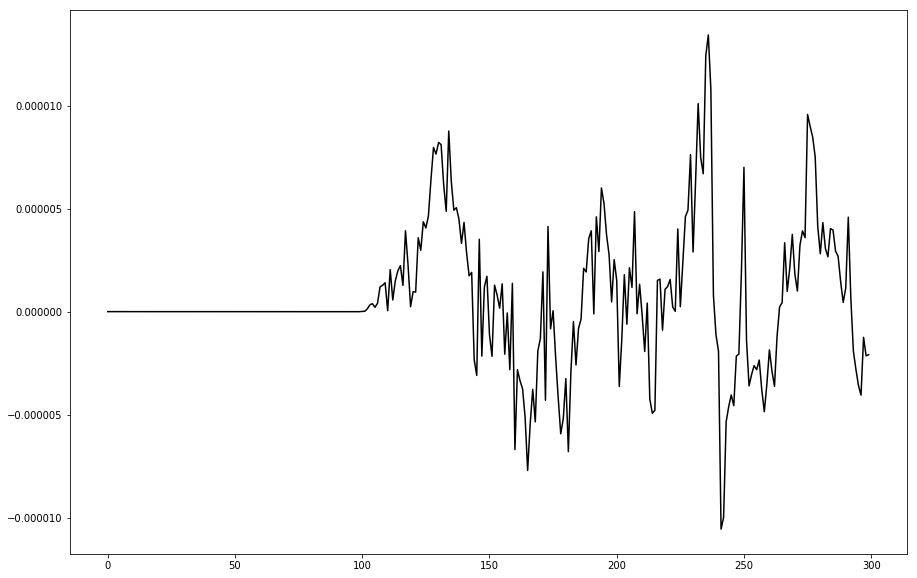

In [4]:
plt.plot(event.raw_image_sensor_response.north[0, :], color="black")

Below I plot the average time series of all pixels. Because can. Interestingly one sees an emerging pattern. Pretty wild right?

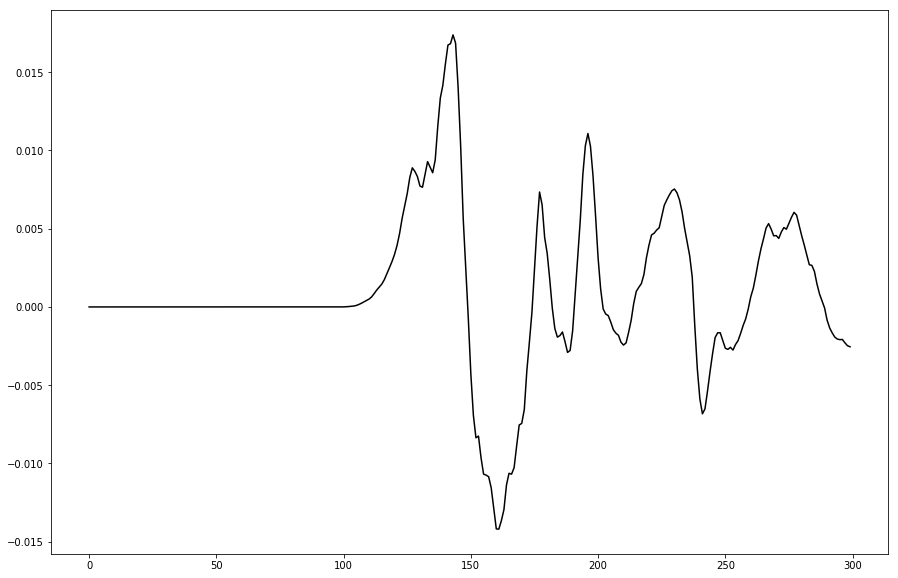

In [5]:
plt.plot(event.raw_image_sensor_response.north.sum(axis=0), color="black")

The energy density $u$ in units of Energy per square meter can be calculated like this 
$$
u = \epsilon_0 c \left( \Delta t \sum_{t_i} \|E(t_i)\|^2 \right)
$$

At least I think so. According to this Wikipedia page here: https://en.wikipedia.org/wiki/Spectral_density#Energy_spectral_density the power/energy density of a signal can be calculated as 

$$ E=\int _{-\infty }^{\infty }|x(t)|^{2}\,dt $$

I just made it discrete and added some constants to get the right units. Our signal however has 3 spatial dimensions so I take the vector norm.

In [6]:
north = event.raw_image_sensor_response.north[0, :]
west = event.raw_image_sensor_response.west[0, :]
vertical = event.raw_image_sensor_response.vertical[0, :]

E = np.vstack([north, west, vertical])

E_abs = np.linalg.norm(E, axis=0) * u.Unit("V/m")

density = const.c * const.eps0 * sample_duration * np.sum(E_abs**2)
density.to("Joule/m^2")

<Quantity 5.3281909435605435e-21 J / m2>

A power spectrogram of the first few pixel in the camera. They all seem to behave in a similar fashion. The window shape and size of the FFT are arbitrary choices made by me. I chose these values because the look good. I chose a Gaussian window since everything is always gaussian in physics isn't it? I have no clue about signal processing.

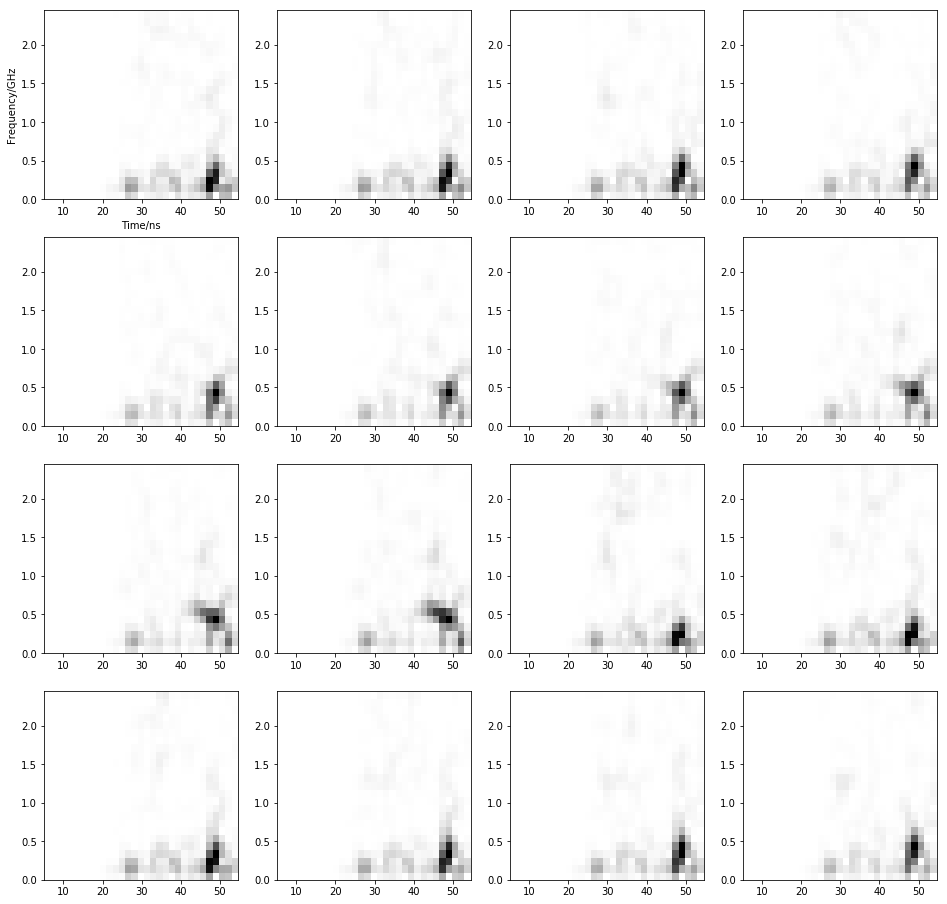

In [7]:
def plot_spectra():
    window_length = 51
    window = signal.gaussian(window_length, std=7)

    fig, axs = plt.subplots(4, 4, figsize=(16, 16))
    axs = np.ravel(axs)
    for pix, ax in enumerate(axs):
        ts = event.raw_image_sensor_response.north[pix, :]
        f, t, Sxx = signal.spectrogram(
            ts,
            sampling_frequency.si.value,
            window=window,
            nperseg=window_length,
            noverlap=window_length - 8,
        )

        ax.pcolormesh(t * 1e9, f / 1e9, Sxx, cmap="gray_r")

    axs[0].set_ylabel("Frequency/GHz")
    axs[0].set_xlabel("Time/ns")


plot_spectra()

Now I append all the time series together and build a larger more detaield frequency spectrum. Hopefully this can give a clue about what kind of bandwidth our reciever should be build for.
If I understand antennas correclty (and let's be honest, I don't) a smaller bandwidth means less noise. 

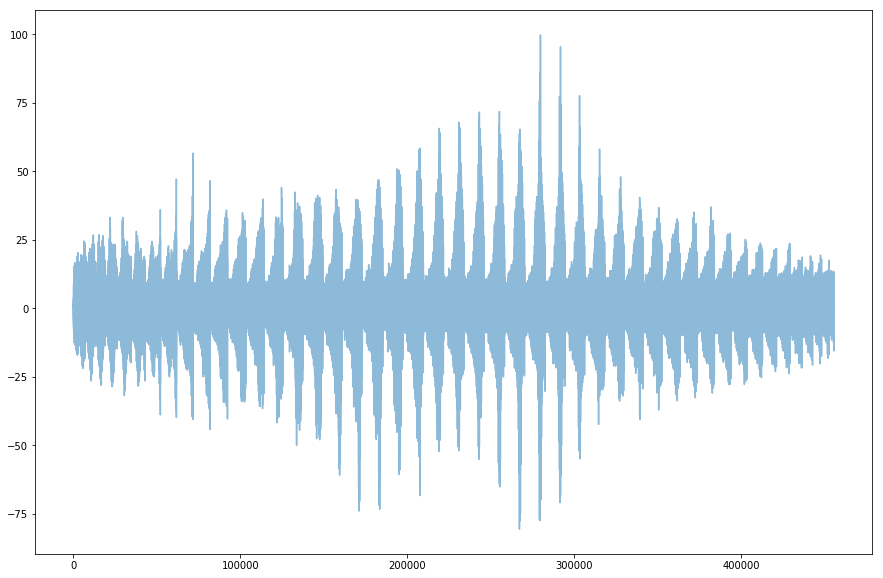

In [8]:
ts = np.ravel(event.raw_image_sensor_response.north)
plt.plot(ts * 1e6, alpha=0.5)

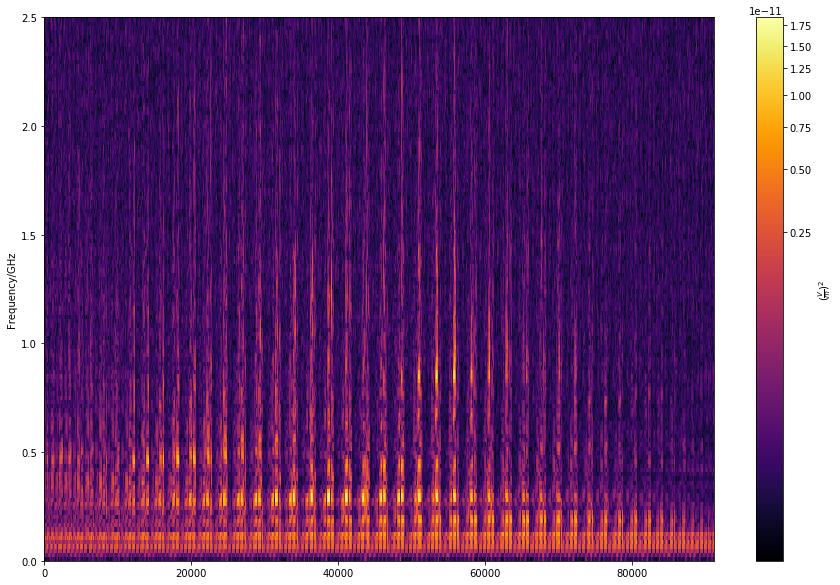

In [9]:
from matplotlib.colors import PowerNorm

f, t, Sxx = signal.spectrogram(
    ts, sampling_frequency.si.value, scaling="spectrum"
)

plt.figure(figsize=(15, 10))
plt.pcolormesh(t * 1e9, f / 1e9, Sxx, norm=PowerNorm(0.25), cmap="inferno")
cb = plt.colorbar()
cb.set_label("$(\\frac{V}{m})^2$")
plt.ylabel("Frequency/GHz")
None

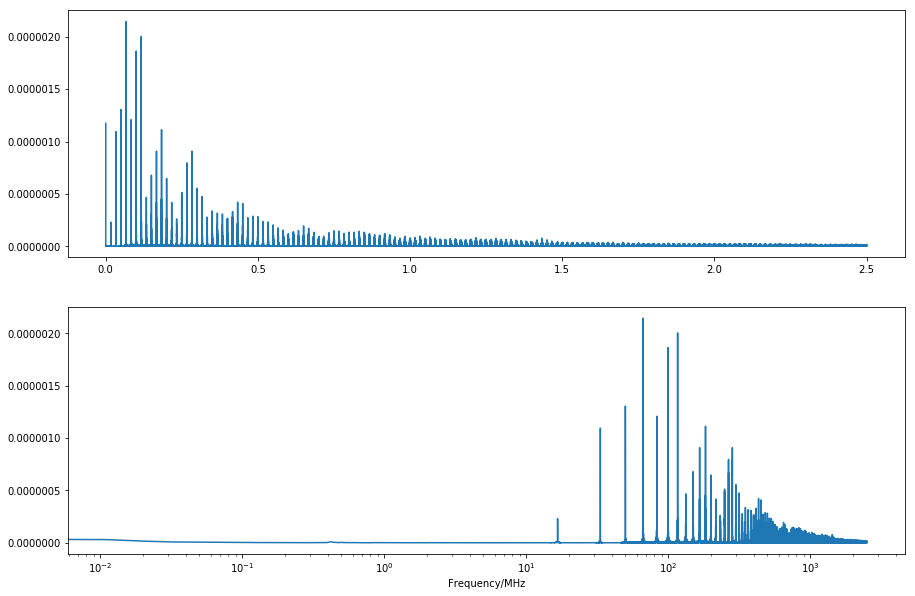

In [10]:
from scipy.fftpack import fft

N = len(ts)

yf = fft(ts)
xf = np.linspace(0.0, 1.0 / (2.0 * sample_duration), N // 2)
fig, (ax1, ax2) = plt.subplots(2, 1)
ax1.plot(xf * 1e-9, 2.0 / N * np.abs(yf[0 : N // 2]))
ax2.set_xlabel("Frequency/GHz")

ax2.plot(xf * 1e-6, 2.0 / N * np.abs(yf[0 : N // 2]))
ax2.set_xscale("log")
ax2.set_xlabel("Frequency/MHz")
None

Seems like most power lies around the 100 MHz band. Which would explain why experiments like the Auger Engineering Radio Array (AERA) operate in these wavelengths. However they also say that GHz coverage would be too expensive. These lowly plebians know nothing I say!